## 2.RNNによる画像生成


###(1)Fashion-MNISTの画像を表示

100%|██████████| 26421880/26421880 [00:00<00:00, 108746513.49it/s]


Extracting ./data/FashionMNIST/raw/train-images-idx3-ubyte.gz to ./data/FashionMNIST/raw



100%|██████████| 29515/29515 [00:00<00:00, 117787709.38it/s]

Extracting ./data/FashionMNIST/raw/train-labels-idx1-ubyte.gz to ./data/FashionMNIST/raw



100%|██████████| 4422102/4422102 [00:00<00:00, 64937033.20it/s]

Extracting ./data/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to ./data/FashionMNIST/raw


100%|██████████| 5148/5148 [00:00<00:00, 23167679.18it/s]

Extracting ./data/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/FashionMNIST/raw



データの数: 60000


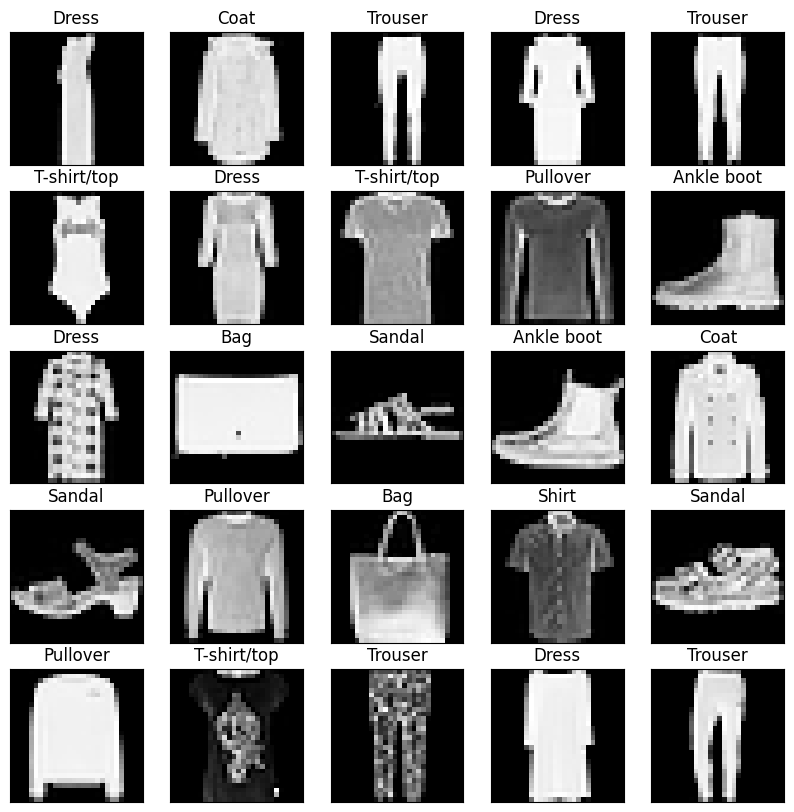

In [1]:
from torchvision.datasets import FashionMNIST
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

fmnist_data = FashionMNIST(root="./data",
                            train=True,download=True,
                            transform=transforms.ToTensor())
fmnist_classes = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
                  "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]
print("データの数:", len(fmnist_data))

n_image = 25  # 表示する画像の数
fmnist_loader = DataLoader(fmnist_data, batch_size=n_image, shuffle=True)
dataiter = iter(fmnist_loader)  # イテレータ
images, labels = next(dataiter)  # 最初のバッチを取り出す

img_size = 28
plt.figure(figsize=(10,10))  # 画像の表示サイズ
for i in range(n_image):
    ax = plt.subplot(5,5,i+1)
    ax.imshow(images[i].view(img_size, img_size), cmap="Greys_r")
    label = fmnist_classes[labels[i]]
    ax.set_title(label)
    ax.get_xaxis().set_visible(False)  # 軸を非表示に
    ax.get_yaxis().set_visible(False)

plt.show()

###(2)データの前処理

In [2]:
import torch
from torch.utils.data import TensorDataset

n_time = 14  # 時刻の数(28の半分)
n_in = img_size  # 入力層のニューロン数
n_mid = 256  # 中間層のニューロン数
n_out = img_size  # 出力層のニューロン数
n_sample_in_img = img_size-n_time  # 1枚の画像中のサンプル数

dataloader = DataLoader(fmnist_data, batch_size=len(fmnist_data), shuffle=False)
dataiter = iter(dataloader)  # イテレータ
train_imgs, labels = next(dataiter)  # データを取り出す
train_imgs = train_imgs.view(-1, img_size, img_size)

n_sample = len(train_imgs) * n_sample_in_img  # サンプル数

input_data = torch.zeros((n_sample, n_time, n_in))  # 入力
correct_data = torch.zeros((n_sample, n_out))  # 正解
for i in range(len(train_imgs)):
    for j in range(n_sample_in_img):
        sample_id = i*n_sample_in_img + j
        input_data[sample_id] = train_imgs[i, j:j+n_time]
        correct_data[sample_id] = train_imgs[i, j+n_time]

dataset = TensorDataset(input_data, correct_data)  # データセットの作成
train_loader = DataLoader(dataset, batch_size=128, shuffle=True)  # DataLoaderの設定

###(3)テスト用データの設定

In [3]:
n_disp = 10  # 生成し表示する画像の数

disp_data = FashionMNIST(root="./data",
                            train=False,download=True,
                            transform=transforms.ToTensor())
disp_loader = DataLoader(disp_data, batch_size=n_disp, shuffle=False)
dataiter = iter(disp_loader)  # イテレータ
disp_imgs, labels = next(dataiter)  # データを取り出す
disp_imgs = disp_imgs.view(-1, img_size, img_size)

###(4)LSTMモデルの構築

In [4]:
import torch.nn as nn

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.rnn = nn.LSTM(  # LSTM層
            input_size=n_in,  # 入力サイズ
            hidden_size=n_mid,  # ニューロン数
            batch_first=True,  # 入力を (バッチサイズ, 時刻の数, 入力の数) にする
        )
        self.fc = nn.Linear(n_mid, n_out)  # 全結合層

    def forward(self, x):
        # y_rnn:全時刻の出力 h:中間層の最終時刻の値 c:記憶セル
        #y_rnn, h = self.rnn(x, None)#GRUとRNNのとき
        y_rnn, (h, c) = self.rnn(x, None)#LSTMのとき
        y = self.fc(y_rnn[:, -1, :])  # yは最後の時刻の出力
        return y

net = Net()
net.cuda()  # GPU対応
print(net)

Net(
  (rnn): LSTM(28, 256, batch_first=True)
  (fc): Linear(in_features=256, out_features=28, bias=True)
)


###(5)画像生成用の関数

In [5]:
def generate_images():
    # オリジナルの画像
    print("Original:")
    plt.figure(figsize=(20, 2))
    for i in range(n_disp):
        ax = plt.subplot(1, n_disp, i+1)
        ax.imshow(disp_imgs[i], cmap="Greys_r", vmin=0.0, vmax=1.0)
        ax.get_xaxis().set_visible(False)  # 軸を非表示に
        ax.get_yaxis().set_visible(False)
    plt.show()

    # 下半分をRNNにより生成した画像
    print("Generated:")
    net.eval()  # 評価モード
    gen_imgs = disp_imgs.clone()
    plt.figure(figsize=(20, 2))
    for i in range(n_disp):
        for j in range(n_sample_in_img):
            x = gen_imgs[i, j:j+n_time].view(1, n_time, img_size)
            x = x.cuda()  # GPU対応
            gen_imgs[i, j+n_time] = net(x)[0]
        ax = plt.subplot(1, n_disp, i+1)
        ax.imshow(gen_imgs[i].detach(), cmap="Greys_r", vmin=0.0, vmax=1.0)
        ax.get_xaxis().set_visible(False)  # 軸を非表示に
        ax.get_yaxis().set_visible(False)
    plt.show()

###(6)RNNモデルの訓練と画像生成

Epoch: 0 Loss_Train: 0.01188319329990881
Original:


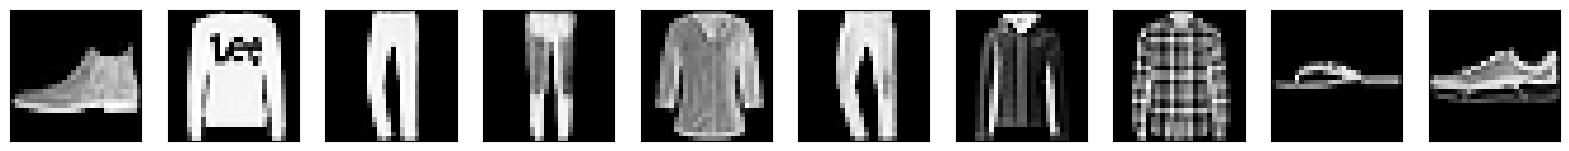

Generated:


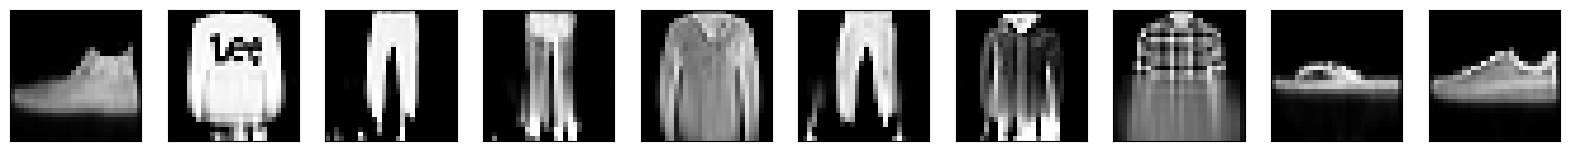

Epoch: 2 Loss_Train: 0.01113967283548137
Original:


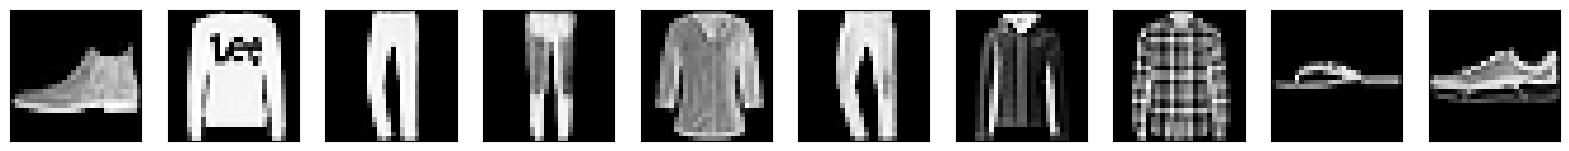

Generated:


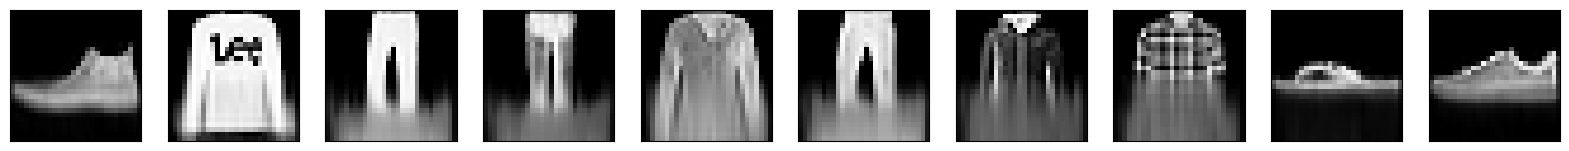

In [7]:
from torch import optim

# 平均二乗誤差
loss_fnc = nn.MSELoss()

# 最適化アルゴリズム
optimizer = optim.Adam(net.parameters())

# 損失のログ
record_loss_train = []

# 学習
epochs = 3  # エポック数
for i in range(epochs):
    net.train()  # 訓練モード
    loss_train = 0
    for j, (x, t) in enumerate(train_loader):  # ミニバッチ（x, t）を取り出す
        x, t = x.cuda(), t.cuda()  # GPU対応
        y = net(x)
        loss = loss_fnc(y, t)
        loss_train += loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    loss_train /= j+1
    record_loss_train.append(loss_train)

    if i%5==0 or i==epochs-1:
        print("Epoch:", i, "Loss_Train:", loss_train)
        generate_images()

### (7)誤差の推移

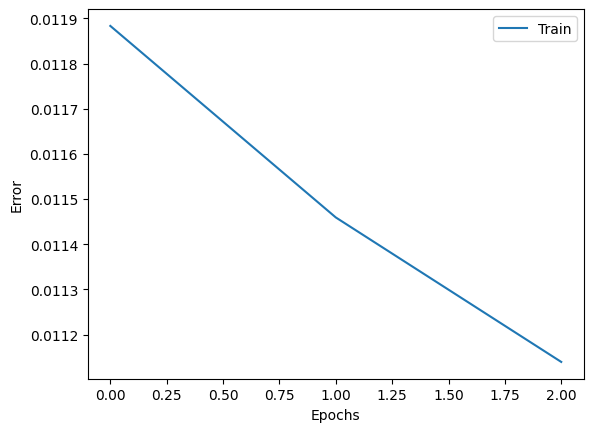

In [8]:
plt.plot(range(len(record_loss_train)), record_loss_train, label="Train")
plt.legend()

plt.xlabel("Epochs")
plt.ylabel("Error")
plt.show()

# 課題3<br>
LSTMの中間層の大きさを変えたときについて考察しなさい。<br>
hidden_size=○, ○, ○

Net(
  (rnn): LSTM(28, 250, batch_first=True)
  (fc): Linear(in_features=250, out_features=28, bias=True)
)
Epoch: 0 Loss_Train: 0.017543524359248587
Original:


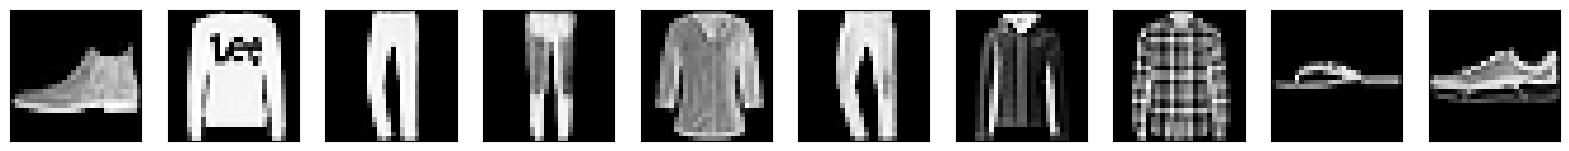

Generated:


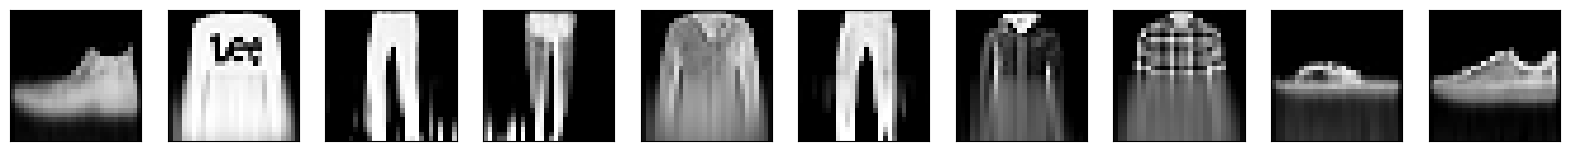

Epoch: 2 Loss_Train: 0.012413625018769069
Original:


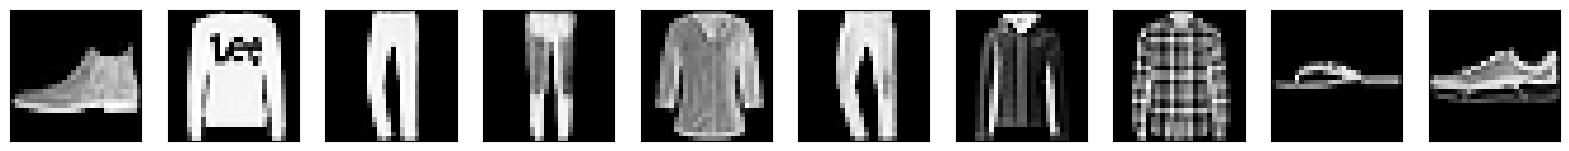

Generated:


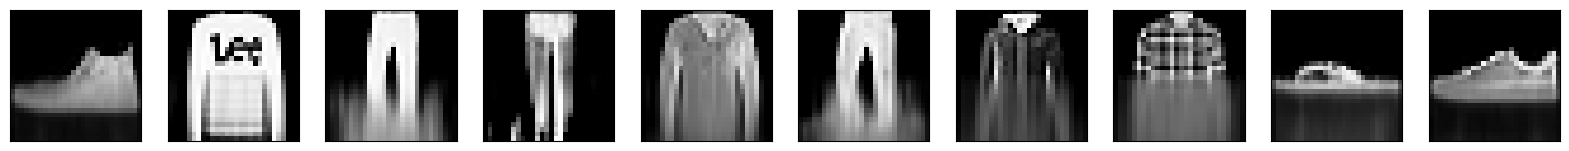

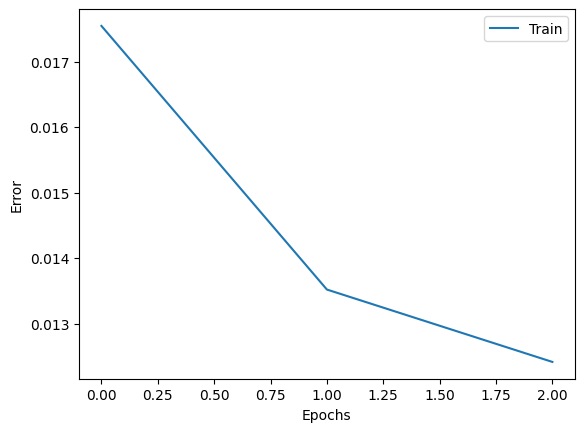

In [13]:
import torch.nn as nn

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.rnn = nn.LSTM(  # LSTM層
            input_size=n_in,  # 入力サイズ
            hidden_size=250,  # ニューロン数
            batch_first=True,  # 入力を (バッチサイズ, 時刻の数, 入力の数) にする
        )
        self.fc = nn.Linear(250, n_in)  # 全結合層

    def forward(self, x):
        # y_rnn:全時刻の出力 h:中間層の最終時刻の値 c:記憶セル
        #y_rnn, h = self.rnn(x, None)#GRUとRNNのとき
        y_rnn, (h, c) = self.rnn(x, None)#LSTMのとき
        y = self.fc(y_rnn[:, -1, :])  # yは最後の時刻の出力
        return y

net = Net()
net.cuda()  # GPU対応
print(net)

###
def generate_images():
    # オリジナルの画像
    print("Original:")
    plt.figure(figsize=(20, 2))
    for i in range(n_disp):
        ax = plt.subplot(1, n_disp, i+1)
        ax.imshow(disp_imgs[i], cmap="Greys_r", vmin=0.0, vmax=1.0)
        ax.get_xaxis().set_visible(False)  # 軸を非表示に
        ax.get_yaxis().set_visible(False)
    plt.show()

    # 下半分をRNNにより生成した画像
    print("Generated:")
    net.eval()  # 評価モード
    gen_imgs = disp_imgs.clone()
    plt.figure(figsize=(20, 2))
    for i in range(n_disp):
        for j in range(n_sample_in_img):
            x = gen_imgs[i, j:j+n_time].view(1, n_time, img_size)
            x = x.cuda()  # GPU対応
            gen_imgs[i, j+n_time] = net(x)[0]
        ax = plt.subplot(1, n_disp, i+1)
        ax.imshow(gen_imgs[i].detach(), cmap="Greys_r", vmin=0.0, vmax=1.0)
        ax.get_xaxis().set_visible(False)  # 軸を非表示に
        ax.get_yaxis().set_visible(False)
    plt.show()

###
from torch import optim

# 平均二乗誤差
loss_fnc = nn.MSELoss()

# 最適化アルゴリズム
optimizer = optim.Adam(net.parameters())

# 損失のログ
record_loss_train = []

# 学習
epochs = 3  # エポック数
for i in range(epochs):
    net.train()  # 訓練モード
    loss_train = 0
    for j, (x, t) in enumerate(train_loader):  # ミニバッチ（x, t）を取り出す
        x, t = x.cuda(), t.cuda()  # GPU対応
        y = net(x)
        loss = loss_fnc(y, t)
        loss_train += loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    loss_train /= j+1
    record_loss_train.append(loss_train)

    if i%5==0 or i==epochs-1:
        print("Epoch:", i, "Loss_Train:", loss_train)
        generate_images()
###
plt.plot(range(len(record_loss_train)), record_loss_train, label="Train")
plt.legend()

plt.xlabel("Epochs")
plt.ylabel("Error")
plt.show()

#課題4<br>
LSTMをモデルに使用しているが、<br>
GRUやRNNに変更したときと比較しなさい。


Net(
  (rnn): GRU(28, 256, batch_first=True)
  (fc): Linear(in_features=256, out_features=28, bias=True)
)
Epoch: 0 Loss_Train: 0.017362778337492703
Original:


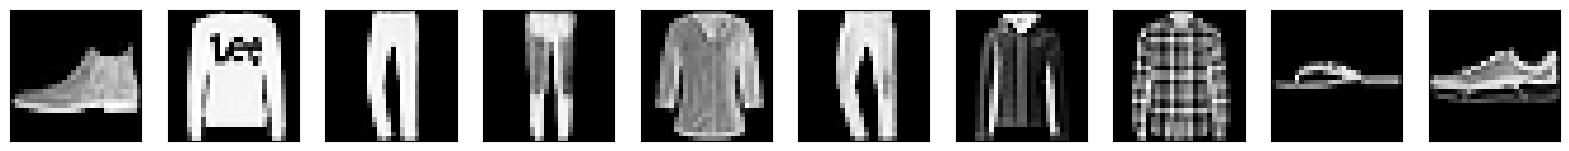

Generated:


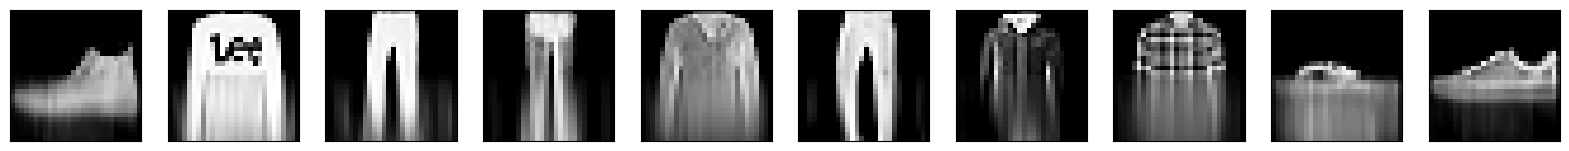

Epoch: 5 Loss_Train: 0.011532022282648642
Original:


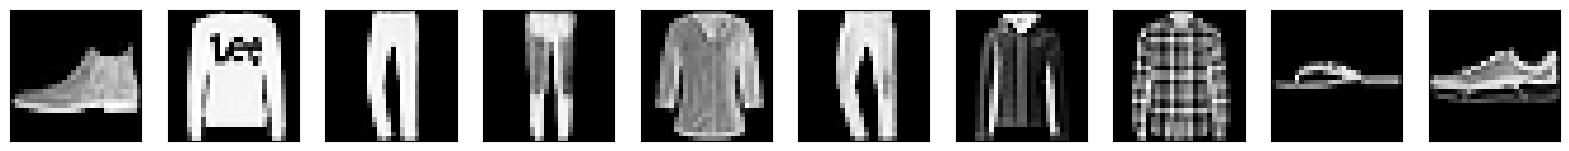

Generated:


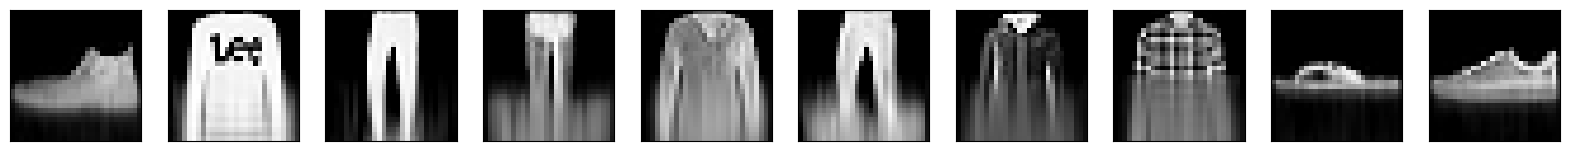

Epoch: 9 Loss_Train: 0.010888628698102126
Original:


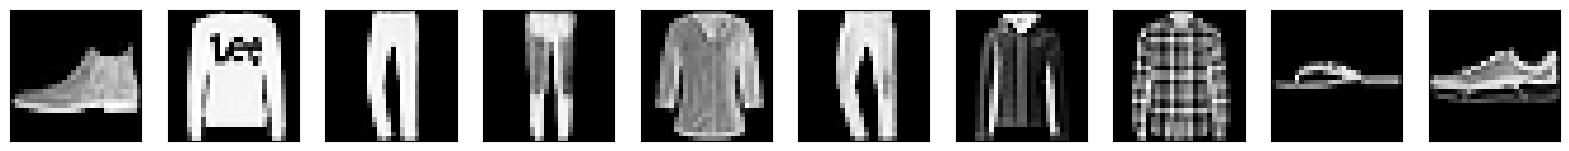

Generated:


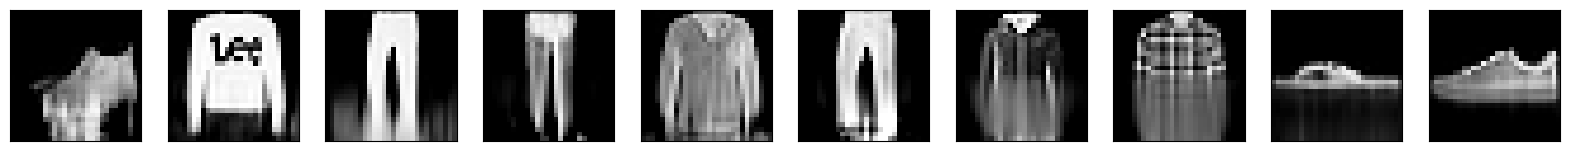

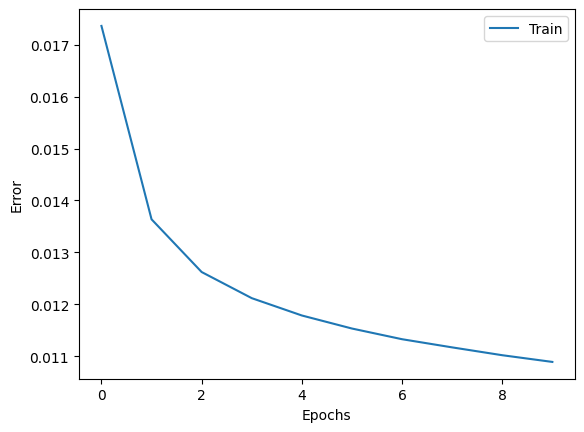

In [14]:
import torch.nn as nn

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.rnn = nn.GRU(  # LSTM層
            input_size=n_in,  # 入力サイズ
            hidden_size=n_mid,  # ニューロン数
            batch_first=True,  # 入力を (バッチサイズ, 時刻の数, 入力の数) にする
        )
        self.fc = nn.Linear(n_mid, n_out)  # 全結合層

    def forward(self, x):
        # y_rnn:全時刻の出力 h:中間層の最終時刻の値 c:記憶セル
        y_rnn, h = self.rnn(x, None)#GRUとRNNのとき
        #y_rnn, (h, c) = self.rnn(x, None)#LSTMのとき
        y = self.fc(y_rnn[:, -1, :])  # yは最後の時刻の出力
        return y

net = Net()
net.cuda()  # GPU対応
print(net)

###
def generate_images():
    # オリジナルの画像
    print("Original:")
    plt.figure(figsize=(20, 2))
    for i in range(n_disp):
        ax = plt.subplot(1, n_disp, i+1)
        ax.imshow(disp_imgs[i], cmap="Greys_r", vmin=0.0, vmax=1.0)
        ax.get_xaxis().set_visible(False)  # 軸を非表示に
        ax.get_yaxis().set_visible(False)
    plt.show()

    # 下半分をRNNにより生成した画像
    print("Generated:")
    net.eval()  # 評価モード
    gen_imgs = disp_imgs.clone()
    plt.figure(figsize=(20, 2))
    for i in range(n_disp):
        for j in range(n_sample_in_img):
            x = gen_imgs[i, j:j+n_time].view(1, n_time, img_size)
            x = x.cuda()  # GPU対応
            gen_imgs[i, j+n_time] = net(x)[0]
        ax = plt.subplot(1, n_disp, i+1)
        ax.imshow(gen_imgs[i].detach(), cmap="Greys_r", vmin=0.0, vmax=1.0)
        ax.get_xaxis().set_visible(False)  # 軸を非表示に
        ax.get_yaxis().set_visible(False)
    plt.show()

###
from torch import optim

# 平均二乗誤差
loss_fnc = nn.MSELoss()

# 最適化アルゴリズム
optimizer = optim.Adam(net.parameters())

# 損失のログ
record_loss_train = []

# 学習
epochs = 10  # エポック数
for i in range(epochs):
    net.train()  # 訓練モード
    loss_train = 0
    for j, (x, t) in enumerate(train_loader):  # ミニバッチ（x, t）を取り出す
        x, t = x.cuda(), t.cuda()  # GPU対応
        y = net(x)
        loss = loss_fnc(y, t)
        loss_train += loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    loss_train /= j+1
    record_loss_train.append(loss_train)

    if i%5==0 or i==epochs-1:
        print("Epoch:", i, "Loss_Train:", loss_train)
        generate_images()
###
plt.plot(range(len(record_loss_train)), record_loss_train, label="Train")
plt.legend()

plt.xlabel("Epochs")
plt.ylabel("Error")
plt.show()